# Assignment 9: GBDT

#### Response Coding: Example

<img src='http://i.imgur.com/TufZptV.jpg' width=700px>

> The response tabel is built only on train dataset.
> For a category which is not there in train data and present in test data, we will encode them with default values
Ex: in our test data if have State: D then we encode it as [0.5, 0.05]

<ol>
    <li><strong>Apply GBDT on these feature sets</strong>
        <ul>
            <li><font color='red'>Set 1</font>: categorical(instead of one hot encoding, try <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/handling-categorical-and-numerical-features/'>response coding</a>: use probability values), numerical features + project_title(TFIDF)+  preprocessed_eassay (TFIDF)+sentiment Score of eassay(check the bellow example, include all 4 values as 4 features)</li>
            <li><font color='red'>Set 2</font>: categorical(instead of one hot encoding, try <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/handling-categorical-and-numerical-features/'>response coding</a>: use probability values), numerical features + project_title(TFIDF W2V)+  preprocessed_eassay (TFIDF W2V)</li>        </ul>
    </li>
    <li><strong>The hyper paramter tuning (Consider any two hyper parameters)</strong>
        <ul>
    <li>Find the best hyper parameter which will give the maximum <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/receiver-operating-characteristic-curve-roc-curve-and-auc-1/'>AUC</a> value</li>
    <li>find the best hyper paramter using k-fold cross validation/simple cross validation data</li>
    <li>use gridsearch cv or randomsearch cv or you can write your own for loops to do this task</li>
        </ul>
    </li>
    <li>
    <strong>Representation of results</strong>
        <ul>
    <li>You need to plot the performance of model both on train data and cross validation data for each hyper parameter, like shown in the figure
    <img src='https://i.imgur.com/Gp2DQmh.jpg' width=500px> with X-axis as <strong>n_estimators</strong>, Y-axis as <strong>max_depth</strong>, and Z-axis as <strong>AUC Score</strong> , we have given the notebook which explains how to plot this 3d plot, you can find it in the same drive <i>3d_scatter_plot.ipynb</i></li>
            <p style="text-align:center;font-size:30px;color:red;"><strong>or</strong></p> <br>
    <li>You need to plot the performance of model both on train data and cross validation data for each hyper parameter, like shown in the figure
    <img src='https://i.imgur.com/fgN9aUP.jpg' width=300px> <a href='https://seaborn.pydata.org/generated/seaborn.heatmap.html'>seaborn heat maps</a> with rows as <strong>n_estimators</strong>, columns as <strong>max_depth</strong>, and values inside the cell representing <strong>AUC Score</strong> </li>
    <li>You choose either of the plotting techniques out of 3d plot or heat map</li>
    <li>Once after you found the best hyper parameter, you need to train your model with it, and find the AUC on test data and plot the ROC curve on both train and test.
    <img src='https://i.imgur.com/wMQDTFe.jpg' width=300px></li>
    <li>Along with plotting ROC curve, you need to print the <a href='https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/confusion-matrix-tpr-fpr-fnr-tnr-1/'>confusion matrix</a> with predicted and original labels of test data points
    <img src='https://i.imgur.com/IdN5Ctv.png' width=300px></li>
            </ul>
    <br>
    <li>You need to summarize the results at the end of the notebook, summarize it in the table format
        <img src='http://i.imgur.com/YVpIGGE.jpg' width=400px>
    </li>
</ol>

In [180]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# import nltk
# nltk.download('vader_lexicon')

sid = SentimentIntensityAnalyzer()

for_sentiment = 'a person is a person no matter how small dr seuss i teach the smallest students with the biggest enthusiasm \
for learning my students learn in many different ways using all of our senses and multiple intelligences i use a wide range\
of techniques to help all my students succeed students in my class come from a variety of different backgrounds which makes\
for wonderful sharing of experiences and cultures including native americans our school is a caring community of successful \
learners which can be seen through collaborative student project based learning in and out of the classroom kindergarteners \
in my class love to work with hands on materials and have many different opportunities to practice a skill before it is\
mastered having the social skills to work cooperatively with friends is a crucial aspect of the kindergarten curriculum\
montana is the perfect place to learn about agriculture and nutrition my students love to role play in our pretend kitchen\
in the early childhood classroom i have had several kids ask me can we try cooking with real food i will take their idea \
and create common core cooking lessons where we learn important math and writing concepts while cooking delicious healthy \
food for snack time my students will have a grounded appreciation for the work that went into making the food and knowledge \
of where the ingredients came from as well as how it is healthy for their bodies this project would expand our learning of \
nutrition and agricultural cooking recipes by having us peel our own apples to make homemade applesauce make our own bread \
and mix up healthy plants from our classroom garden in the spring we will also create our own cookbooks to be printed and \
shared with families students will gain math and literature skills as well as a life long enjoyment for healthy cooking \
nannan'
ss = sid.polarity_scores(for_sentiment)

for k in ss:
    print('{0}: {1}, '.format(k, ss[k]), end='')

# we can use these 4 things as features/attributes (neg, neu, pos, compound)
# neg: 0.0, neu: 0.753, pos: 0.247, compound: 0.93

neg: 0.01, neu: 0.745, pos: 0.245, compound: 0.9975, 

<h1>1. GBDT (xgboost/lightgbm) </h1>

## 1.1 Loading Data

In [181]:
import os
import warnings
warnings.filterwarnings("ignore")
import pandas
from tqdm import tqdm
import pandas
data = pandas.read_csv('preprocessed_data.csv',nrows=50000)
data.columns
print(len(data))

50000


# Calculating sentiment score for pre-processed eassy

In [182]:
sid_for_data = SentimentIntensityAnalyzer()
eassy_negative = []
eassy_positive = []
eassy_neutral = []
eassy_compound = []
for essay in tqdm(data['essay']):
    neg = sid_for_data.polarity_scores(essay)['neg']
    pos = sid_for_data.polarity_scores(essay)['pos']
    neu = sid_for_data.polarity_scores(essay)['neu']
    compound = sid_for_data.polarity_scores(essay)['compound']
    eassy_negative.append(neg)
    eassy_positive.append(pos)
    eassy_neutral.append(neu)
    eassy_compound.append(compound)

100%|████████████████████████████████████████████████████████████████████████████| 50000/50000 [19:53<00:00, 41.91it/s]


In [183]:
data['negative'] = eassy_negative
data['positive'] = eassy_positive
data['neutral'] = eassy_neutral
data['compound'] = eassy_compound

In [184]:
maj_class = data[data['project_is_approved'] == 1]
min_class = data[data['project_is_approved'] == 0]
print(maj_class.shape,min_class.shape)

(41993, 13) (8007, 13)


In [185]:
# Y= data['project_is_approved']
# X= data.drop(['project_is_approved'], axis=1)

<h2>1.2 Splitting data into Train and cross validation(or test): Stratified Sampling</h2>

In [186]:
# please write all the code with proper documentation, and proper titles for each subsection
# go through documentations and blogs before you start coding
# first figure out what to do, and then think about how to do.
# reading and understanding error messages will be very much helpfull in debugging your code
# when you plot any graph make sure you use 
    # a. Title, that describes your plot, this will be very helpful to the reader
    # b. Legends if needed
    # c. X-axis label
    # d. Y-axis label
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(data, data['project_is_approved'],
                                                    test_size = 0.33, stratify = data['project_is_approved'],
                                                    random_state = 42)    

In [187]:
X_test

,school_state,teacher_prefix,project_grade_category,teacher_number_of_previously_posted_projects,project_is_approved,clean_categories,clean_subcategories,essay,price,negative,positive,neutral,compound
15662,tn,mrs,grades_prek_2,1,1,history_civics literacy_language,history_geography literacy,our students come lower income families studen...,289.00,0.022,0.304,0.674,0.9925
18563,al,mrs,grades_3_5,0,1,appliedlearning,other,i learn better i able move a student telling t...,199.00,0.042,0.173,0.784,0.9403
36171,ut,ms,grades_9_12,0,1,math_science,mathematics,our students come large diverse high school ou...,1374.36,0.029,0.134,0.837,0.9371
6472,tx,mrs,grades_9_12,0,0,math_science appliedlearning,appliedsciences college_careerprep,my students amazing group 7th 12th graders ver...,433.26,0.013,0.213,0.774,0.9821
11001,ga,ms,grades_3_5,0,1,literacy_language math_science,literacy mathematics,my third grade class typically made diverse gr...,107.06,0.039,0.211,0.750,0.9826
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28722,fl,mrs,grades_prek_2,9,0,health_sports,health_wellness nutritioneducation,each day i like start class rocking we are fam...,301.15,0.044,0.289,0.667,0.9851
24500,ca,mr,grades_6_8,42,1,health_sports,nutritioneducation,my students athletes students interested healt...,532.91,0.009,0.179,0.813,0.9622
24480,ca,mrs,grades_3_5,6,1,appliedlearning,college_careerprep,how many times day rely computer technology we...,1910.47,0.021,0.141,0.838,0.9747
5388,tx,mrs,grades_6_8,0,0,appliedlearning,communityservice extracurricular,the students sewing club help children need th...,115.81,0.065,0.243,0.692,0.9850


# Responsive code logic for categorical data

Responsive coding explanation :
   Function merge_encoding_data call Response_code_logic function . Now Response_code_logic function call Response_table_logic_function which calculate the functionality of responsive coding and maps it with repective column feature.Finally merge_encoding_data return the dataframe with a column of prob_positive_value and prob_negative_value for the training dataset.
   
   
   For testing data-set we are using Laplace smoothing,we are not using the responsive code logic here seperately,instead we are using the value of of pos and neg feature for each feature column of train-data and if a vale is not present then we are taking the value of pos and neg test data as 0.5 repectively 

In [188]:
def Response_table_logic(table, col) :
    cat = table[col].unique()
    
    freq_1 = []
    for i in cat : 
        freq_1.append(len(table.loc[(table[col] == i) & (table['project_is_approved'] == 1)]))
        
        
    freq_0 = []
    for i in cat : 
        freq_0.append(len(table.loc[(table[col] == i) & (table['project_is_approved'] == 0)]))
        
    
    encoded_1 = []
    for i in range(len(cat)) :
        encoded_1.append(freq_1[i]/(freq_1[i] + freq_0[i]))
    
    encoded_0 = []
    encoded_0[:] = [1 - x for x in encoded_1]
        
    encoded_1_val = dict(zip(cat, encoded_1)) 
    encoded_0_val = dict(zip(cat, encoded_0)) 
    
    return encoded_1_val, encoded_0_val

In [189]:
import pandas as pd
def Response_code_logic(table) : 
    one_cleancat, zero_cleancat = Response_table_logic(table,'clean_categories')
    one_cleansubcat, zero_cleansubcat = Response_table_logic(table,'clean_subcategories')
    one_schoolstate, zero_schoolstate = Response_table_logic(table, 'school_state')
    one_teacherprefix, zero_teacherprefix = Response_table_logic(table, 'teacher_prefix')
    one_projgradecat, zero_projgradecat = Response_table_logic(table, 'project_grade_category')
    
    df = pd.DataFrame()
    df['clean_cat_1'] = table['clean_categories'].map(one_cleancat)
    df['clean_cat_0'] = table['clean_categories'].map(zero_cleancat)
    df['clean_subcat_1'] = table['clean_subcategories'].map(one_cleansubcat)
    df['clean_subcat_0'] = table['clean_subcategories'].map(zero_cleansubcat)
    df['school_state_1'] = table['school_state'].map(one_schoolstate)
    df['school_state_0'] = table['school_state'].map(zero_schoolstate)
    df['teacher_prefix_1'] = table['teacher_prefix'].map(one_teacherprefix)
    df['teacher_prefix_0'] = table['teacher_prefix'].map(zero_teacherprefix)
    df['proj_grade_cat_1'] = table['project_grade_category'].map(one_projgradecat)
    df['proj_grade_cat_0'] = table['project_grade_category'].map(zero_projgradecat)

    return df


In [190]:
Response_Train = Response_code_logic(X_train)
#Response_Test = Response_code_logic(X_test)


In [191]:
Response_Train.columns

Index(['clean_cat_1', 'clean_cat_0', 'clean_subcat_1', 'clean_subcat_0',
       'school_state_1', 'school_state_0', 'teacher_prefix_1',
       'teacher_prefix_0', 'proj_grade_cat_1', 'proj_grade_cat_0'],
      dtype='object')

<h2>1.4 Make Data Model Ready: encoding numerical, categorical features</h2>

In [192]:
# please write all the code with proper documentation, and proper titles for each subsection
# go through documentations and blogs before you start coding 
# first figure out what to do, and then think about how to do.
# reading and understanding error messages will be very much helpfull in debugging your code
# make sure you featurize train and test data separatly

# when you plot any graph make sure you use 
    # a. Title, that describes your plot, this will be very helpful to the reader
    # b. Legends if needed
    # c. X-axis label
    # d. Y-axis label
def merge_encoding_data(table, p, n) :
    lstPos = table[p].values.tolist()
    lstNeg = table[n].values.tolist()
    frame = pd.DataFrame(list(zip(lstNeg, lstPos)))
    
    return frame    

In [193]:
Response_Train.columns

Index(['clean_cat_1', 'clean_cat_0', 'clean_subcat_1', 'clean_subcat_0',
       'school_state_1', 'school_state_0', 'teacher_prefix_1',
       'teacher_prefix_0', 'proj_grade_cat_1', 'proj_grade_cat_0'],
      dtype='object')

# Applying responive code on all the categorical data

# Response coding to school state

In [194]:
X_train = X_train.reset_index()
# X_test.reset_index()   

In [195]:
# please write all the code with proper documentation, and proper titles for each subsection
# go through documentations and blogs before you start coding
# first figure out what to do, and then think about how to do.
# reading and understanding error messages will be very much helpfull in debugging your code
# when you plot any graph make sure you use 
    # a. Title, that describes your plot, this will be very helpful to the reader
    # b. Legends if needed
    # c. X-axis label
    # d. Y-axis label
    
x_train_school_state = merge_encoding_data(Response_Train, 'school_state_1', 'school_state_0')
X_temp_train_school_state = pd.concat([x_train_school_state,X_train["school_state"],X_train["project_is_approved"]],axis=1)
X_temp_train_school_state = X_temp_train_school_state.drop_duplicates()
X_temp_train_school_state = X_temp_train_school_state.reset_index()
#print(X_temp_train_school_state)
#x_test_school_state = merge_encoding_data(Response_Test, 'school_state_1', 'school_state_0')

# print(x_train_school_state.shape, Y_train.shape)
# print(x_cross_val_school_state.shape, Y_test.shape)    

In [196]:
# X_train.columns

In [197]:
different_cat_school_state = set(X_train['school_state'].astype('category').tolist())
different_cat_school_state = list(different_cat_school_state)
#print(different_cat_school_state)

In [198]:
x_test_school_state =pd.DataFrame()
pos_value = []
neg_value = []
for value in X_test["school_state"]:
    if value in different_cat_school_state:
        row = X_temp_train_school_state.loc[X_temp_train_school_state['school_state'] == value]
        val = row[0].tolist()
        neg_value.append(val[0])
        pos_value.append(1-val[0])
    else:
        neg_value.append(0.5)
        pos_value.append(0.5)
x_test_school_state["school_state_pos"] = pos_value
x_test_school_state["school_state_neg"] = neg_value

# Response coding to teacher prefix

In [199]:
different_cat_teacher_prefix = set(X_train["teacher_prefix"].astype('category').tolist())
different_cat_teacher_prefix = list(different_cat_teacher_prefix)
#print(different_cat_teacher_prefix)

In [200]:
import pandas as pd
x_train_teacher_prefix = merge_encoding_data(Response_Train, 'teacher_prefix_1', 'teacher_prefix_0')
#x_test_teacher_prefix = merge_encoding_data(Response_Test, 'teacher_prefix_1', 'teacher_prefix_0')
#print(x_train_teacher_prefix)
X_temp_train_teacher_prefix = pd.concat([x_train_teacher_prefix,X_train["teacher_prefix"],X_train["project_is_approved"]],axis=1)
X_temp_train_teacher_prefix = X_temp_train_teacher_prefix.drop_duplicates()
X_temp_train_teacher_prefix = X_temp_train_teacher_prefix.reset_index()
#print(X_temp_train_teacher_prefix)

In [201]:
#x_test_teacher_prefix = merge_encoding_data(Response_Test, 'teacher_prefix_1', 'teacher_prefix_0')
#print(type(x_test_teacher_prefix))
x_test_teacher_prefix =pd.DataFrame()
pos_value = []
neg_value = []
for value in X_test["teacher_prefix"]:
    if value in different_cat_teacher_prefix:
        row = X_temp_train_teacher_prefix.loc[X_temp_train_teacher_prefix['teacher_prefix'] == value]
        val = row[0].tolist()
        neg_value.append(val[0])
        pos_value.append(1-val[0])
    else:
        neg_value.append(0.5)
        pos_value.append(0.5)
x_test_teacher_prefix["teacher_prefix_pos"] = pos_value
x_test_teacher_prefix["teacher_prefix_neg"] = neg_value

# Response coding to project grade 

In [202]:
different_cat_project_grade_category = set(X_train["project_grade_category"].astype('category').tolist())
different_cat_project_grade_category = list(different_cat_project_grade_category)
#print(different_cat_project_grade_category)

In [203]:
x_train_project_grade_category = merge_encoding_data(Response_Train, 'proj_grade_cat_1', 'proj_grade_cat_0')
X_temp_train_project_grade_category = pd.concat([x_train_project_grade_category,X_train["project_grade_category"],X_train["project_is_approved"]],axis=1)
X_temp_train_project_grade_category = X_temp_train_project_grade_category.drop_duplicates()
X_temp_train_project_grade_category = X_temp_train_project_grade_category.reset_index()
#print(X_temp_train_project_grade_category)
#x_test_project_grade_category = merge_encoding_data(Response_Test, 'proj_grade_cat_1', 'proj_grade_cat_0')

In [204]:
x_test_project_grade_category =pd.DataFrame()
pos_value = []
neg_value = []
for value in X_test["project_grade_category"]:
    if value in different_cat_project_grade_category:
        row = X_temp_train_project_grade_category.loc[X_temp_train_project_grade_category['project_grade_category'] == value]
        val = row[0].tolist()
        neg_value.append(val[0])
        pos_value.append(1-val[0])
    else:
        neg_value.append(0.5)
        pos_value.append(0.5)
x_test_project_grade_category["project_grade_category_pos"] = pos_value
x_test_project_grade_category["project_grade_category_neg"] = neg_value

# Response coding to clean category

In [205]:
different_cat_clean_categories = set(X_train["clean_categories"].astype('category').tolist())
different_cat_clean_categories = list(different_cat_clean_categories)
#print(different_cat_clean_categories)

In [206]:
x_train_clean_categories = merge_encoding_data(Response_Train, 'clean_cat_1', 'clean_cat_0')
X_temp_train_clean_categories = pd.concat([x_train_clean_categories,X_train["clean_categories"],X_train["project_is_approved"]],axis=1)
X_temp_train_clean_categories = X_temp_train_clean_categories.drop_duplicates()
X_temp_train_clean_categories = X_temp_train_clean_categories.reset_index()
#print(X_temp_train_clean_categories)
#x_test_clean_categories = merge_encoding_data(Response_Test, 'clean_cat_1', 'clean_cat_0')

In [207]:
x_test_clean_categories =pd.DataFrame()
pos_value = []
neg_value = []
for value in X_test["clean_categories"]:
    if value in different_cat_clean_categories:
        row = X_temp_train_clean_categories.loc[X_temp_train_clean_categories['clean_categories'] == value]
        val = row[0].tolist()
        neg_value.append(val[0])
        pos_value.append(1-val[0])
    else:
        neg_value.append(0.5)
        pos_value.append(0.5)
x_test_clean_categories["clean_categories_pos"] = pos_value
x_test_clean_categories["clean_categories_neg"] = neg_value

# Response coding to clean sub category

In [208]:
different_cat_clean_subcategories = set(X_train["clean_subcategories"].astype('category').tolist())
different_cat_clean_subcategories = list(different_cat_clean_subcategories)
#print(different_cat_clean_subcategories)

In [209]:
x_train_clean_subcategories = merge_encoding_data(Response_Train, 'clean_subcat_1', 'clean_subcat_0')
X_temp_train_clean_subcategories = pd.concat([x_train_clean_subcategories,X_train["clean_subcategories"],X_train["project_is_approved"]],axis=1)
X_temp_train_clean_subcategories = X_temp_train_clean_subcategories.drop_duplicates()
X_temp_train_clean_subcategories = X_temp_train_clean_subcategories.reset_index()
#print(X_temp_train_clean_subcategories)
#x_test_clean_subcategories = merge_encoding_data(Response_Test, 'clean_subcat_1', 'clean_subcat_0')

In [210]:
x_test_clean_subcategories =pd.DataFrame()
pos_value = []
neg_value = []
for value in X_test["clean_subcategories"]:
    if value in different_cat_clean_subcategories:
        row = X_temp_train_clean_subcategories.loc[X_temp_train_clean_subcategories['clean_subcategories'] == value]
        val = row[0].tolist()
        neg_value.append(val[0])
        pos_value.append(1-val[0])
    else:
        neg_value.append(0.5)
        pos_value.append(0.5)
x_test_clean_subcategories["clean_subcategories_pos"] = pos_value
x_test_clean_subcategories["clean_subcategories_neg"] = neg_value

In [211]:
# differenttest_cat_clean_subcategories = set(X_test["clean_subcategories"].astype('category').tolist())
# print(differenttest_cat_clean_subcategories)

# numerical feature price

In [212]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
standardizer = StandardScaler()

#standardizer.fit(X_train['price'].values.reshape(1, -1))
x_train_price = standardizer.fit_transform(X_train['price'].values.reshape(-1, 1))
#standardizer_test_cross_val = StandardScaler()
x_test_price = standardizer.transform(X_test['price'].values.reshape(-1, 1))


# numerical feature no of teacher previously posted

In [213]:
from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler()

#standardizer.fit(X_train['teacher_number_of_previously_posted_projects'].values.reshape(1, -1))

x_train_teacher_posted_prev = standardizer.fit_transform(X_train['teacher_number_of_previously_posted_projects'].values.reshape(-1, 1))
#standardizer.fit(X_cross_val['teacher_number_of_previously_posted_projects'].values.reshape(1, -1))
#x_cross_val_teacher_posted_prev = standardizer.transform(X_cross_val['teacher_number_of_previously_posted_projects'].values.reshape(-1, 1))
#standardizer.fit(X_test['teacher_number_of_previously_posted_projects'].values.reshape(1, -1))
x_test_teacher_posted_prev = standardizer.transform(X_test['teacher_number_of_previously_posted_projects'].values.reshape(-1, 1))



# numerical feature positive


In [214]:
from sklearn.preprocessing import StandardScaler
eassy_sentiment = StandardScaler()

#eassy_sentiment.fit(X_train['positive'].values.reshape(1, -1))

x_train_positive = eassy_sentiment.fit_transform(X_train['positive'].values.reshape(-1, 1))
#x_cross_val_positive = eassy_sentiment.transform(X_cross_val['positive'].values.reshape(-1, 1))
x_test_positive = eassy_sentiment.transform(X_test['positive'].values.reshape(-1, 1))



# numerical feature -ve


In [215]:
from sklearn.preprocessing import StandardScaler
eassy_sentiment = StandardScaler()

x_train_negative = eassy_sentiment.fit_transform(X_train['negative'].values.reshape(-1, 1))
x_test_negative = eassy_sentiment.transform(X_test['negative'].values.reshape(-1, 1))


# numerical feature neutral

In [216]:
from sklearn.preprocessing import StandardScaler
eassy_sentiment = StandardScaler()


x_train_neutral = eassy_sentiment.fit_transform(X_train['neutral'].values.reshape(-1, 1))
x_test_neutral = eassy_sentiment.transform(X_test['neutral'].values.reshape(-1, 1))



# numerical feature compound


In [217]:
from sklearn.preprocessing import StandardScaler
eassy_sentiment = StandardScaler()

x_train_compound = eassy_sentiment.fit_transform(X_train['compound'].values.reshape(-1, 1))
x_test_compound = eassy_sentiment.transform(X_test['compound'].values.reshape(-1, 1))

# vectorize eassy using TFIDF

In [218]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_idf_vect = TfidfVectorizer()
tf_idf_vect.fit(X_train['essay'].values)

# using the fitted model to convert text to vector

x_train_essay_tfidf = tf_idf_vect.transform(X_train['essay'].values)
#x_cross_val_essay_tfidf = tf_idf_vect.transform(X_cross_val['essay'].values)
x_test_essay_tfidf = tf_idf_vect.transform(X_test['essay'].values)

# vectorizing eassy using TFIDF-W2V

In [219]:
import pickle
with open('glove_vectors', 'rb') as f:
    model = pickle.load(f)
    glove_words =  set(model.keys())

In [220]:
tf_idf_w2v = TfidfVectorizer()
tf_idf_w2v.fit(X_train["essay"])
dictionary = dict(zip(tf_idf_w2v.get_feature_names(), list(tf_idf_w2v.idf_)))
tfidf_words = set(tf_idf_w2v.get_feature_names())

In [221]:
import numpy as np
x_train_essay_tfidf_w2v = []; 
for sentence in tqdm(X_train["essay"]): 
    vector = np.zeros(300) 
    tf_idf_weight =0; 
    for word in sentence.split(): 
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] 
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) 
            vector += (vec * tf_idf) 
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    x_train_essay_tfidf_w2v.append(vector)

print(len(x_train_essay_tfidf_w2v))
print(len(x_train_essay_tfidf_w2v))

100%|███████████████████████████████████████████████████████████████████████████| 33500/33500 [04:23<00:00, 127.30it/s]

33500
33500


In [222]:
x_test_essay_tfidf_w2v = []; 
for sentence in tqdm(X_test["essay"]): 
    vector = np.zeros(300) 
    tf_idf_weight =0; 
    for word in sentence.split(): 
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] 
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) 
            vector += (vec * tf_idf) 
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    x_test_essay_tfidf_w2v.append(vector)
    
print(len(x_test_essay_tfidf_w2v))
print(len(x_test_essay_tfidf_w2v[0]))

100%|███████████████████████████████████████████████████████████████████████████| 16500/16500 [02:09<00:00, 127.45it/s]

16500
300


# summing all features of set -1 (Vectorize(TFIDF))

In [223]:
from scipy.sparse import hstack
all_X_train_tfidf_sample = hstack((x_train_essay_tfidf,x_train_school_state,x_train_teacher_prefix,x_train_project_grade_category,x_train_clean_categories,x_train_clean_subcategories,
                                 x_train_price,x_train_teacher_posted_prev,x_train_negative,x_train_positive,x_train_neutral,x_train_compound)).tocsr()

all_X_test_tfidf_sample =  hstack((x_test_essay_tfidf,x_test_school_state,x_test_teacher_prefix,x_test_project_grade_category,x_test_clean_categories,x_test_clean_subcategories,
                                 x_test_price,x_test_teacher_posted_prev,x_test_negative,x_test_positive,x_test_neutral,x_test_compound)).tocsr()

# Hyperparameter tuning

In [224]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [225]:
GBDT = GradientBoostingClassifier()
parameters = {'max_depth': [1,3,5,7],'n_estimators': [5, 10, 50, 100]}

clf = GridSearchCV(GBDT, parameters, cv=3, scoring='roc_auc',return_train_score=True)
clf.fit(all_X_train_tfidf_sample,Y_train)

GridSearchCV(cv=3, error_score=nan,
             estimator=GradientBoostingClassifier(ccp_alpha=0.0,
                                                  criterion='friedman_mse',
                                                  init=None, learning_rate=0.1,
                                                  loss='deviance', max_depth=3,
                                                  max_features=None,
                                                  max_leaf_nodes=None,
                                                  min_impurity_decrease=0.0,
                                                  min_impurity_split=None,
                                                  min_samples_leaf=1,
                                                  min_samples_split=2,
                                                  min_weight_fraction_leaf=0.0,
                                                  n_estimators=100,
                                                  n_iter_no_change=None,
         

In [226]:
#clf.cv_results_

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
max_scores = pd.DataFrame(clf.cv_results_).groupby(['param_n_estimators','param_max_depth']).max().unstack()[['mean_test_score', 'mean_train_score']]
#print(max_scores[['mean_test_score', 'mean_train_score']])
fig, ax = plt.subplots(1,2, figsize=(20,6))
#print(max_scores.mean_train_score)
sns.heatmap(max_scores.mean_train_score, annot = True, fmt='.4g', ax=ax[0])
sns.heatmap(max_scores.mean_test_score, annot = True, fmt='.4g', ax=ax[1])

ax[0].set_title('Train Set')
ax[1].set_title('CV Set')

plt.show()

In [228]:
print(clf.best_estimator_)
#Mean cross-validated score of the best_estimator
print(clf.score(all_X_train_tfidf_sample,Y_train))
print(clf.score(all_X_test_tfidf_sample,Y_test))

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=100,
                           n_iter_no_change=None, presort='deprecated',
                           random_state=None, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)
0.790428331912555
0.6619280598749575


# Training model with the best hyper-parameter

In [229]:
from sklearn.metrics import roc_curve, auc
tfidf_sample = GradientBoostingClassifier(max_depth = 3, n_estimators=100)
tfidf_sample.fit(all_X_train_tfidf_sample, Y_train)

Y_train_pred = tfidf_sample.predict_proba(all_X_train_tfidf_sample)[:, 1]
Y_test_pred = tfidf_sample.predict_proba(all_X_test_tfidf_sample)[:, 1]

train_false_positive_rate, train_true_positive_rate, train_thresholds = roc_curve(Y_train, Y_train_pred)
test_false_positive_rate, test_true_positive_rate, test_thresholds = roc_curve(Y_test, Y_test_pred)

print("Train AUC Score: ", auc(train_false_positive_rate, train_true_positive_rate))
print("Test AUC Score: ", auc(test_false_positive_rate, test_true_positive_rate))

Train AUC Score:  0.790428331912555
Test AUC Score:  0.6615580530281784


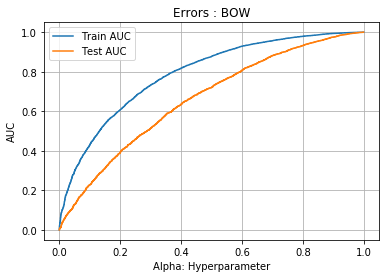

In [230]:
plt.plot(train_false_positive_rate, train_true_positive_rate, label = "Train AUC")
plt.plot(test_false_positive_rate, test_true_positive_rate, label = "Test AUC")

plt.legend()
plt.xlabel("Alpha: Hyperparameter")
plt.ylabel("AUC")
plt.title("Errors : BOW")
plt.grid()
plt.show()

# Confusion Matrix

In [231]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix 
prediction_train = []
prediction_test = []
def label_conversion(proba, threshold, fpr, tpr,value):
  
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    t = threshold[np.argmax(tpr*(1-fpr))]
    predictions = []
    for i in proba:
        if i>=t:
            predictions.append(1)
        else:
            predictions.append(0)
    if value == "train":
        prediction_train.extend(predictions)
    if value == "test":
        prediction_test.extend(predictions)    
    return predictions

conf_matrix_test = confusion_matrix(Y_test, label_conversion(Y_test_pred, test_thresholds, test_false_positive_rate, test_true_positive_rate,"test"))
conf_matrix_train = confusion_matrix(Y_train, label_conversion(Y_train_pred, train_thresholds, train_false_positive_rate, train_true_positive_rate,"train"))

[Text(0,0.5,'negative'), Text(0,1.5,'positive')]

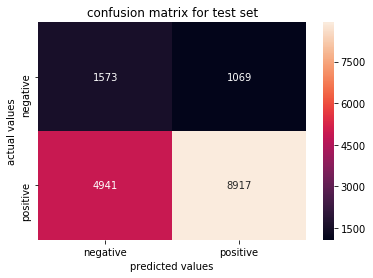

In [232]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_map = plt.subplot()
sns.heatmap(conf_matrix_test, annot = True, ax = heat_map, fmt= 'g')

heat_map.set_ylabel("actual values")
heat_map.set_xlabel("predicted values")
heat_map.set_title("confusion matrix for test set")
heat_map.xaxis.set_ticklabels(['negative', 'positive'])
heat_map.yaxis.set_ticklabels(['negative', 'positive'])

[Text(0,0.5,'negative'), Text(0,1.5,'positive')]

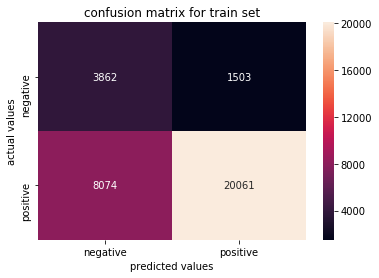

In [233]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_map = plt.subplot()
sns.heatmap(conf_matrix_train, annot = True, ax = heat_map, fmt= 'g')

heat_map.set_ylabel("actual values")
heat_map.set_xlabel("predicted values")
heat_map.set_title("confusion matrix for train set")
heat_map.xaxis.set_ticklabels(['negative', 'positive'])
heat_map.yaxis.set_ticklabels(['negative', 'positive'])

# summing all features of set -2 (Vectorize(TFIDF_W2V))

In [234]:
all_X_train_tfidfw2v_sample = hstack((x_train_essay_tfidf_w2v,x_train_school_state,x_train_teacher_prefix,x_train_project_grade_category,x_train_clean_categories,x_train_clean_subcategories,
                                 x_train_price,x_train_teacher_posted_prev,x_train_negative,x_train_positive,x_train_neutral,x_train_compound)).tocsr()

all_X_test_tfidfw2v_sample =  hstack((x_test_essay_tfidf_w2v,x_test_school_state,x_test_teacher_prefix,x_test_project_grade_category,x_test_clean_categories,x_test_clean_subcategories,
                                 x_test_price,x_test_teacher_posted_prev,x_test_negative,x_test_positive,x_test_neutral,x_test_compound)).tocsr()


# Hyperparameter tuning

In [235]:
GBDT = GradientBoostingClassifier()

parameters = {'max_depth': [1,3,5,7],'n_estimators':[5,10,50,100]}

clf_2 = GridSearchCV(GBDT, parameters, cv=3, scoring='roc_auc',return_train_score=True)
clf_2.fit(all_X_train_tfidfw2v_sample,Y_train)

GridSearchCV(cv=3, error_score=nan,
             estimator=GradientBoostingClassifier(ccp_alpha=0.0,
                                                  criterion='friedman_mse',
                                                  init=None, learning_rate=0.1,
                                                  loss='deviance', max_depth=3,
                                                  max_features=None,
                                                  max_leaf_nodes=None,
                                                  min_impurity_decrease=0.0,
                                                  min_impurity_split=None,
                                                  min_samples_leaf=1,
                                                  min_samples_split=2,
                                                  min_weight_fraction_leaf=0.0,
                                                  n_estimators=100,
                                                  n_iter_no_change=None,
         

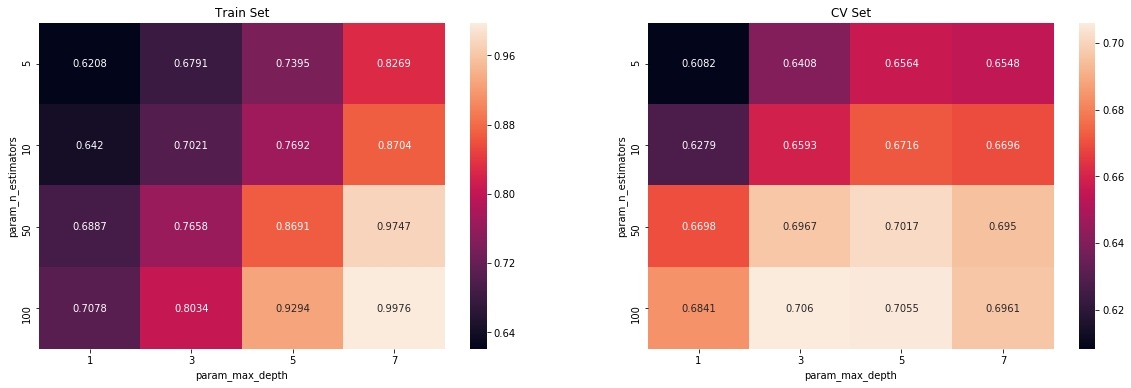

In [236]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
max_scores = pd.DataFrame(clf_2.cv_results_).groupby(['param_n_estimators','param_max_depth']).max().unstack()[['mean_test_score', 'mean_train_score']]
#print(max_scores[['mean_test_score', 'mean_train_score']])
fig, ax = plt.subplots(1,2, figsize=(20,6))

sns.heatmap(max_scores.mean_train_score, annot = True, fmt='.4g', ax=ax[0])
sns.heatmap(max_scores.mean_test_score, annot = True, fmt='.4g', ax=ax[1])

ax[0].set_title('Train Set')
ax[1].set_title('CV Set')

plt.show()

# Training the model with best hyper-parameter

In [237]:
#Best Estimator and Best tune parameters
print(clf_2.best_estimator_)
#Mean cross-validated score of the best_estimator
print(clf_2.score(all_X_train_tfidfw2v_sample,Y_train))
print(clf_2.score(all_X_test_tfidfw2v_sample,Y_test))

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=100,
                           n_iter_no_change=None, presort='deprecated',
                           random_state=None, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)
0.7806324651928667
0.6327455758958416


In [238]:
print(clf_2.best_estimator_)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=100,
                           n_iter_no_change=None, presort='deprecated',
                           random_state=None, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


In [239]:
from sklearn.metrics import roc_curve, auc
tfidfw2v_sample = GradientBoostingClassifier(max_depth = 3,n_estimators=100 )
tfidfw2v_sample.fit(all_X_train_tfidfw2v_sample, Y_train)

Y_train_pred = tfidfw2v_sample.predict_proba(all_X_train_tfidfw2v_sample)[:, 1]
Y_test_pred = tfidfw2v_sample.predict_proba(all_X_test_tfidfw2v_sample)[:, 1]

train_false_positive_rate, train_true_positive_rate, train_thresholds = roc_curve(Y_train, Y_train_pred)
test_false_positive_rate, test_true_positive_rate, test_thresholds = roc_curve(Y_test, Y_test_pred)

print("Train AUC Score: ", auc(train_false_positive_rate, train_true_positive_rate))
print("Test AUC Score: ", auc(test_false_positive_rate, test_true_positive_rate))

Train AUC Score:  0.7806324651928667
Test AUC Score:  0.6328886951013574


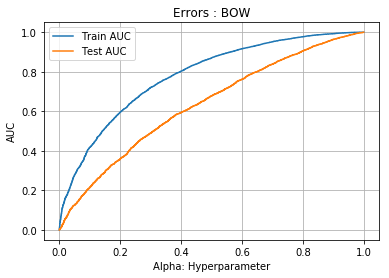

In [240]:
plt.plot(train_false_positive_rate, train_true_positive_rate, label = "Train AUC")
plt.plot(test_false_positive_rate, test_true_positive_rate, label = "Test AUC")

plt.legend()
plt.xlabel("Alpha: Hyperparameter")
plt.ylabel("AUC")
plt.title("Errors : BOW")
plt.grid()
plt.show()

# Calculating confusion matrix

In [241]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix 
prediction_train = []
prediction_test = []
def label_conversion(proba, threshold, fpr, tpr,value):
  
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    t = threshold[np.argmax(tpr*(1-fpr))]
    predictions = []
    for i in proba:
        if i>=t:
            predictions.append(1)
        else:
            predictions.append(0)
    if value == "train":
        prediction_train.extend(predictions)
    if value == "test":
        prediction_test.extend(predictions)    
    return predictions

conf_matrix_test = confusion_matrix(Y_test, label_conversion(Y_test_pred, test_thresholds, test_false_positive_rate, test_true_positive_rate,"test"))
conf_matrix_train = confusion_matrix(Y_train, label_conversion(Y_train_pred, train_thresholds, train_false_positive_rate, train_true_positive_rate,"train"))

[Text(0,0.5,'negative'), Text(0,1.5,'positive')]

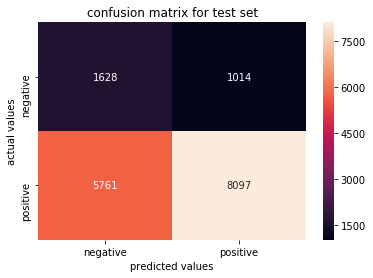

In [242]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_map = plt.subplot()
sns.heatmap(conf_matrix_test, annot = True, ax = heat_map, fmt= 'g')

heat_map.set_ylabel("actual values")
heat_map.set_xlabel("predicted values")
heat_map.set_title("confusion matrix for test set")
heat_map.xaxis.set_ticklabels(['negative', 'positive'])
heat_map.yaxis.set_ticklabels(['negative', 'positive'])

[Text(0,0.5,'negative'), Text(0,1.5,'positive')]

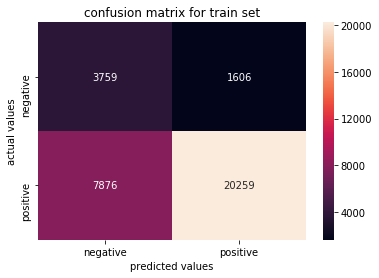

In [243]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_map = plt.subplot()
sns.heatmap(conf_matrix_train, annot = True, ax = heat_map, fmt= 'g')

heat_map.set_ylabel("actual values")
heat_map.set_xlabel("predicted values")
heat_map.set_title("confusion matrix for train set")
heat_map.xaxis.set_ticklabels(['negative', 'positive'])
heat_map.yaxis.set_ticklabels(['negative', 'positive'])

<h1>3. Summary</h1>

<br> as mentioned in the step 4 of instructions

In [245]:
from prettytable import PrettyTable
TB = PrettyTable()
TB.field_names = ["Model",  "Train_AUC", "Test_Auc"]
TB.title = "GBDT"
TB.add_row(["TFIDF-Model", 0.79, 0.62])
TB.add_row(["tfidfW2v-Model", 0.78, 0.63])
print(TB)    

+----------------+-----------+----------+
|     Model      | Train_AUC | Test_Auc |
+----------------+-----------+----------+
|  TFIDF-Model   |    0.79   |   0.62   |
| tfidfW2v-Model |    0.78   |   0.63   |
+----------------+-----------+----------+
